In [12]:
# -------------------------------------------------------------------------
# Step 1: Data Ingestion, Cleaning & Feature Normalization
# -------------------------------------------------------------------------
import os        # Navigate Kaggle directory structure and manipulate file paths
import glob      # Automatically locate and match all '.csv' pattern files in dataset folder
import numpy as np        # Vector/matrix calculations, infinite value handling, random seed control
import pandas as pd       # Load tabular CSV data, clean column names, row sampling to conserve RAM
from sklearn.model_selection import train_test_split   # Split data into train/validation/test sets
from sklearn.preprocessing import StandardScaler       # Scale features to zero mean and unit variance

import warnings
warnings.filterwarnings('ignore')

# Set random seed for exact reproducibility across runs
SEED = 42
np.random.seed(SEED)

# 1. Target the Kaggle dataset directory
DATASET_DIR = "/kaggle/input/datasets/chethuhn/network-intrusion-dataset"
csv_files   = glob.glob(os.path.join(DATASET_DIR, "*.csv"))

print(f"📁 Found {len(csv_files)} CSV file(s) in dataset path.")

📁 Found 8 CSV file(s) in dataset path.


In [13]:
df_list = []
for file_path in csv_files:
    filename = os.path.basename(file_path)
    print(f"   Reading file: {filename}...")
    sub_df = pd.read_csv(file_path, low_memory=False)

    # Downsample each CSV to max 40,000 rows — same limit as VAE notebook
    if len(sub_df) > 40000:
        sub_df = sub_df.sample(n=40000, random_state=SEED)

    df_list.append(sub_df)

# Combine all CSV files into one master dataframe
df = pd.concat(df_list, axis=0, ignore_index=True)

   Reading file: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
   Reading file: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
   Reading file: Tuesday-WorkingHours.pcap_ISCX.csv...
   Reading file: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
   Reading file: Monday-WorkingHours.pcap_ISCX.csv...
   Reading file: Friday-WorkingHours-Morning.pcap_ISCX.csv...
   Reading file: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
   Reading file: Wednesday-workingHours.pcap_ISCX.csv...


In [14]:
df.columns = df.columns.str.strip()

# Dynamically detect target label column
target_col = "Label" if "Label" in df.columns else df.columns[-1]

# 4. Drop network identifier columns that do not contribute to pattern learning
cols_to_drop = [
    c for c in [
        "Flow ID", "Source IP", "Source Port",
        "Destination IP", "Destination Port",
        "Timestamp", "Unnamed: 0",
    ] if c in df.columns
]
df = df.drop(columns=cols_to_drop)

In [15]:
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# 6. Separate features (X) and labels (y)
X_raw = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values
y_raw = df[target_col].astype(str).values

# 7. Binary label encoding: BENIGN = 0, any attack type = 1
y_binary = (y_raw != "BENIGN").astype(int)

print(f"\n📊 Class Distribution (Binary):")
benign_count = int((y_binary == 0).sum())
attack_count = int((y_binary == 1).sum())
total        = len(y_binary)
print(f"   - BENIGN (0) : {benign_count:>8,} samples ({benign_count/total*100:.1f}%)")
print(f"   - ATTACK (1) : {attack_count:>8,} samples ({attack_count/total*100:.1f}%)")


📊 Class Distribution (Binary):
   - BENIGN (0) :  258,121 samples (80.7%)
   - ATTACK (1) :   61,606 samples (19.3%)


In [16]:
# 8. AE trains EXCLUSIVELY on BENIGN traffic
#    At test time it sees both BENIGN and ATTACK to measure separation
X_normal = X_raw[y_binary == 0]   # Only normal traffic for training
X_attack  = X_raw[y_binary == 1]  # Attack traffic reserved for testing

# Split normal traffic into train / validation sets
X_train_raw, X_val_raw = train_test_split(
    X_normal, test_size=0.2, random_state=SEED
)

# Build a balanced test set: equal numbers of normal and attack samples
n_test  = min(len(X_val_raw), len(X_attack))
X_test_raw = np.vstack([X_val_raw[:n_test], X_attack[:n_test]])
y_test     = np.array([0] * n_test + [1] * n_test)

In [17]:
# 9. Normalize features using training statistics only (zero data leakage)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Clip extreme outliers to [-5, 5] range
# CICIDS 2017 has extreme values in features like Flow Bytes/s
# that cause val loss to explode into millions without this
X_train_scaled = np.clip(X_train_scaled, -5, 5)
X_val_scaled   = np.clip(X_val_scaled,   -5, 5)
X_test_scaled  = np.clip(X_test_scaled,  -5, 5)

print(f"   Train range after clip: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")
print(f"   Val   range after clip: [{X_val_scaled.min():.2f},   {X_val_scaled.max():.2f}]")

   Train range after clip: [-5.00, 5.00]
   Val   range after clip: [-5.00,   5.00]


In [18]:
# -------------------------------------------------------------------------
# Step 2: PyTorch Tensors, DataLoaders & Autoencoder Architecture
# -------------------------------------------------------------------------
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Set CUDA seed for exact neural network weight reproducibility
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Detect and select GPU or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Hardware acceleration device selected: {device}")

# 1. Convert NumPy arrays into PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled,   dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled,  dtype=torch.float32)

# 2. Wrap into TensorDatasets (AE uses features only — no labels during training)
train_dataset = TensorDataset(X_train_tensor)
val_dataset   = TensorDataset(X_val_tensor)

# 3. Instantiate DataLoaders (batch size 256 for optimal GPU throughput)
BATCH_SIZE   = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)


# 4. Define the Autoencoder Architecture
class TabularAutoencoder(nn.Module):
    """
    Fully-connected Autoencoder for network traffic anomaly detection.

    Architecture:
        Encoder : input_dim → 128 → 64 → 32 → 16 (bottleneck)
        Decoder : 16 → 32 → 64 → 128 → input_dim

    Detection Logic:
        - Trained EXCLUSIVELY on BENIGN (normal) traffic
        - Normal traffic  → AE reconstructs well  → LOW reconstruction error  ✅
        - Attack traffic  → AE reconstructs poorly → HIGH reconstruction error ❌
        - Threshold set at 95th percentile of normal reconstruction errors
    """

    def __init__(self, input_dim: int, bottleneck: int = 16):
        super(TabularAutoencoder, self).__init__()

        # Encoder: progressively compresses input into compact bottleneck representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, bottleneck),   # Bottleneck — compressed representation
            nn.LeakyReLU(0.2),
        )

        # Decoder: reconstructs original feature vector from bottleneck
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, input_dim),   # Raw output — no activation (MSE loss)
        )

    def forward(self, x):
        z    = self.encoder(x)
        recon = self.decoder(z)
        return recon

    def encode(self, x):
        """Return only the bottleneck representation (for visualization)."""
        return self.encoder(x)


# 5. Instantiate model
input_dim = X_train_scaled.shape[1]
BOTTLENECK = 16

model = TabularAutoencoder(input_dim=input_dim, bottleneck=BOTTLENECK).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n✅ Step 2 Execution Completed:")
print(f"   - Hardware Target     : {device}")
print(f"   - Input Feature Dim   : {input_dim}")
print(f"   - Bottleneck Size     : {BOTTLENECK}")
print(f"   - Total Parameters    : {total_params:,}")
print(f"   - Mini-Batches/Epoch  : {len(train_loader)}")

⚡ Hardware acceleration device selected: cuda

✅ Step 2 Execution Completed:
   - Hardware Target     : cuda
   - Input Feature Dim   : 77
   - Bottleneck Size     : 16
   - Total Parameters    : 42,589
   - Mini-Batches/Epoch  : 807


In [19]:
# Hyperparameters
EPOCHS        = 60
LEARNING_RATE = 1e-3

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

train_losses = []
val_losses   = []
best_val_loss = float('inf')

print(f"🚀 Initializing AE Training for {EPOCHS} Epochs on {device.type.upper()}...")

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # ── Training Phase
    model.train()
    total_train_loss = 0.0
    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)
        recon   = model(x_batch)
        loss    = criterion(recon, x_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation Phase
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for (x_val_b,) in val_loader:
            x_val_b   = x_val_b.to(device)
            recon_val = model(x_val_b)
            total_val_loss += criterion(recon_val, x_val_b).item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # ── Save Best Model (no stopping — just keeps saving best checkpoint)
    status = ""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_ae.pth')
        status = "✅ saved"

    # ── Log every 10 epochs
    epoch_duration = time.time() - epoch_start
    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch [{epoch:02d}/{EPOCHS}] ({epoch_duration:.1f}s) | "
            f"Train Loss: {avg_train_loss:.6f} | "
            f"Val Loss: {avg_val_loss:.6f} | "
            f"LR: {current_lr:.2e} | {status}"
        )

# Load best weights after full training
model.load_state_dict(torch.load('best_ae.pth', map_location=device))
print(f"\n✅ Training Complete — All {EPOCHS} epochs ran.")
print(f"   Best Validation Loss : {best_val_loss:.6f}")

🚀 Initializing AE Training for 60 Epochs on CUDA...
Epoch [01/60] (3.9s) | Train Loss: 0.044780 | Val Loss: 0.015290 | LR: 1.00e-03 | ✅ saved
Epoch [10/60] (3.9s) | Train Loss: 0.007218 | Val Loss: 0.005000 | LR: 1.00e-03 | 
Epoch [20/60] (3.7s) | Train Loss: 0.005383 | Val Loss: 0.003904 | LR: 1.00e-03 | 
Epoch [30/60] (3.8s) | Train Loss: 0.004548 | Val Loss: 0.003303 | LR: 1.00e-03 | 
Epoch [40/60] (3.8s) | Train Loss: 0.004005 | Val Loss: 0.002737 | LR: 1.00e-03 | 
Epoch [50/60] (3.8s) | Train Loss: 0.003088 | Val Loss: 0.002008 | LR: 5.00e-04 | 
Epoch [60/60] (4.0s) | Train Loss: 0.002568 | Val Loss: 0.001507 | LR: 2.50e-04 | ✅ saved

✅ Training Complete — All 60 epochs ran.
   Best Validation Loss : 0.001507


In [20]:
# -------------------------------------------------------------------------
# Step 4: Anomaly Scoring & Threshold Calibration
# -------------------------------------------------------------------------

print("\n🔍 Computing per-sample reconstruction errors on test set...")

model.eval()

with torch.no_grad():
    X_test_gpu = X_test_tensor.to(device)
    X_recon    = model(X_test_gpu)

    # Per-sample MSE reconstruction error (higher = more anomalous)
    recon_errors = torch.mean(
        (X_test_gpu - X_recon) ** 2, dim=1
    ).cpu().numpy()

# Separate errors by true label
normal_errors = recon_errors[y_test == 0]
attack_errors = recon_errors[y_test == 1]

# Threshold: 95th percentile of BENIGN reconstruction errors
# Any sample with error above this is classified as ATTACK
threshold = float(np.percentile(normal_errors, 95))

print(f"\n📊 Reconstruction Error Statistics:")
print(f"   - BENIGN  — Mean: {normal_errors.mean():.6f} | Std: {normal_errors.std():.6f}")
print(f"   - ATTACK  — Mean: {attack_errors.mean():.6f} | Std: {attack_errors.std():.6f}")
print(f"   - Threshold (P95 of BENIGN): {threshold:.6f}")

# Classify: reconstruction error > threshold → ATTACK (1)
y_pred = (recon_errors > threshold).astype(int)

print(f"\n✅ Step 4 Execution Completed.")
print(f"   - Threshold set at 95th percentile of normal errors: {threshold:.6f}")
print(f"   - Samples flagged as ATTACK : {y_pred.sum():,}")
print(f"   - Samples flagged as BENIGN : {(y_pred == 0).sum():,}")




🔍 Computing per-sample reconstruction errors on test set...

📊 Reconstruction Error Statistics:
   - BENIGN  — Mean: 0.001506 | Std: 0.008667
   - ATTACK  — Mean: 0.049696 | Std: 0.102524
   - Threshold (P95 of BENIGN): 0.005425

✅ Step 4 Execution Completed.
   - Threshold set at 95th percentile of normal errors: 0.005425
   - Samples flagged as ATTACK : 26,138
   - Samples flagged as BENIGN : 77,112


In [21]:
# -------------------------------------------------------------------------
# Step 5: Performance Metrics
# -------------------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve
)

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, recon_errors)

print("=" * 65)
print("  AUTOENCODER ANOMALY DETECTION — PERFORMANCE METRICS")
print("=" * 65)
print(f"\n  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"\n  Detailed Classification Report:")
print(
    classification_report(
        y_test, y_pred,
        target_names=["BENIGN", "ATTACK"],
        digits=4,
        zero_division=0
    )
)

print(f"\n✅ Step 5 Execution Completed.")


  AUTOENCODER ANOMALY DETECTION — PERFORMANCE METRICS

  Accuracy  : 0.7031  (70.31%)
  Precision : 0.9012
  Recall    : 0.4563
  F1-Score  : 0.6058
  ROC-AUC   : 0.7617

  Detailed Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.6360    0.9500    0.7619     51625
      ATTACK     0.9012    0.4563    0.6058     51625

    accuracy                         0.7031    103250
   macro avg     0.7686    0.7031    0.6839    103250
weighted avg     0.7686    0.7031    0.6839    103250


✅ Step 5 Execution Completed.


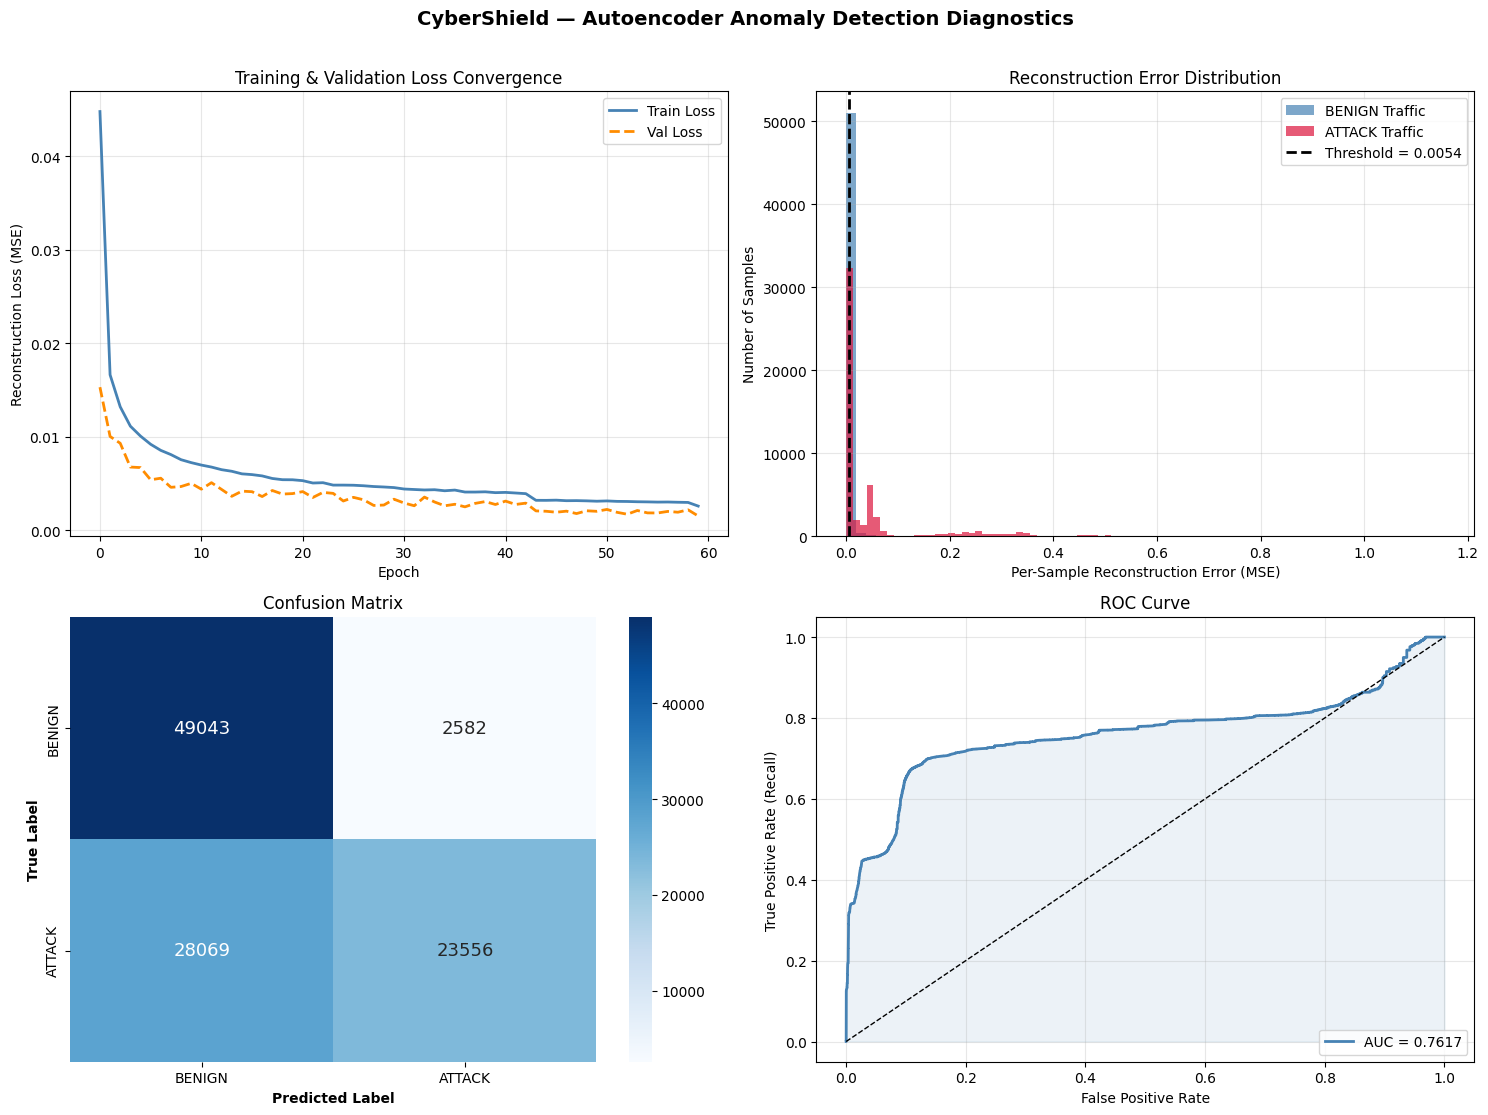


✅ Step 6 Execution Completed.
   - Saved → ae_diagnostics_dashboard.png


In [22]:
# -------------------------------------------------------------------------
# Step 6: Visual Diagnostics Dashboard
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(
    'CyberShield — Autoencoder Anomaly Detection Diagnostics',
    fontsize=14, fontweight='bold', y=1.01
)

# ── Plot 1: Training & Validation Loss Convergence
axes[0, 0].plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
axes[0, 0].plot(val_losses,   label='Val Loss',   color='darkorange',
                linestyle='--', linewidth=2)
axes[0, 0].set_title('Training & Validation Loss Convergence')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Reconstruction Loss (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ── Plot 2: Reconstruction Error Distribution (Normal vs Attack)
axes[0, 1].hist(normal_errors, bins=60, alpha=0.7,
                color='steelblue', label='BENIGN Traffic')
axes[0, 1].hist(attack_errors, bins=60, alpha=0.7,
                color='crimson',  label='ATTACK Traffic')
axes[0, 1].axvline(
    threshold, color='black', linestyle='--', linewidth=2,
    label=f'Threshold = {threshold:.4f}'
)
axes[0, 1].set_title('Reconstruction Error Distribution')
axes[0, 1].set_xlabel('Per-Sample Reconstruction Error (MSE)')
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ── Plot 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
    xticklabels=['BENIGN', 'ATTACK'],
    yticklabels=['BENIGN', 'ATTACK'],
    annot_kws={'size': 13}
)
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_xlabel('Predicted Label', fontweight='bold')
axes[1, 0].set_ylabel('True Label',      fontweight='bold')

# ── Plot 4: ROC Curve
fpr, tpr, _ = roc_curve(y_test, recon_errors)
axes[1, 1].plot(
    fpr, tpr, color='steelblue', linewidth=2,
    label=f'AUC = {roc_auc:.4f}'
)
axes[1, 1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1, 1].set_title('ROC Curve')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate (Recall)')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ae_diagnostics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Step 6 Execution Completed.")
print("   - Saved → ae_diagnostics_dashboard.png")


In [23]:
# -------------------------------------------------------------------------
# Step 7: Performance Matrix Summary
# -------------------------------------------------------------------------
!pip install -q tabulate

import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

print("=" * 65)
print("  AE PERFORMANCE MATRIX")
print("=" * 65)

# ── Table 1: Reconstruction Error Statistics
df_recon = pd.DataFrame({
    "Traffic Type" : ["BENIGN (Normal)", "ATTACK (Anomaly)"],
    "Mean Error"   : [round(float(normal_errors.mean()), 6),
                      round(float(attack_errors.mean()), 6)],
    "Std Error"    : [round(float(normal_errors.std()),  6),
                      round(float(attack_errors.std()),  6)],
    "Min Error"    : [round(float(normal_errors.min()),  6),
                      round(float(attack_errors.min()),  6)],
    "Max Error"    : [round(float(normal_errors.max()),  6),
                      round(float(attack_errors.max()),  6)],
    "Threshold"    : [f"{threshold:.6f} (P95)", "—"],
})

# ── Table 2: Detection Performance
df_detection = pd.DataFrame({
    "Metric"   : ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Value"    : [
        f"{acc:.4f}  ({acc*100:.2f}%)",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{roc_auc:.4f}",
    ],
    "Technical Meaning" : [
        "Overall correct classifications across normal + attack",
        "Of packets flagged as ATTACK — how many were truly attacks",
        "Of all real attacks — how many were successfully detected",
        "Harmonic mean of Precision and Recall (primary metric)",
        "Area under ROC curve — threshold-independent separability",
    ],
})

# ── Table 3: Confusion Matrix Breakdown
tn, fp, fn, tp = cm.ravel()
df_cm = pd.DataFrame({
    "Outcome"     : ["True Negative (TN)", "False Positive (FP)",
                     "False Negative (FN)", "True Positive (TP)"],
    "Count"       : [int(tn), int(fp), int(fn), int(tp)],
    "Meaning"     : [
        "Normal traffic correctly classified as BENIGN",
        "Normal traffic incorrectly flagged as ATTACK (false alarm)",
        "Attack traffic missed — classified as BENIGN (most dangerous)",
        "Attack traffic correctly detected as ATTACK",
    ],
})

# ── Table 4: Training Summary
df_training = pd.DataFrame({
    "Training Metric"         : [
        "Reconstruction Loss (MSE) — Epoch 1",
        "Reconstruction Loss (MSE) — Final Epoch",
        "Best Validation Loss",
        "Total Epochs Trained",
    ],
    "Value" : [
        round(float(train_losses[0]),  6),
        round(float(train_losses[-1]), 6),
        round(float(best_val_loss),    6),
        len(train_losses),
    ],
})

print("\n1. RECONSTRUCTION ERROR STATISTICS")
print(df_recon.to_markdown(index=False))

print("\n2. ANOMALY DETECTION PERFORMANCE")
print(df_detection.to_markdown(index=False))

print("\n3. CONFUSION MATRIX BREAKDOWN")
print(df_cm.to_markdown(index=False))

print("\n4. TRAINING SUMMARY")
print(df_training.to_markdown(index=False))

# Export all tables as CSVs for report inclusion
df_recon.to_csv("ae_reconstruction_error_stats.csv",  index=False)
df_detection.to_csv("ae_detection_performance.csv",   index=False)
df_cm.to_csv("ae_confusion_matrix_breakdown.csv",     index=False)
df_training.to_csv("ae_training_summary.csv",         index=False)

print("\n✅ Step 7 Execution Completed.")
print("   - All performance matrices exported as CSV files.")


  AE PERFORMANCE MATRIX

1. RECONSTRUCTION ERROR STATISTICS
| Traffic Type     |   Mean Error |   Std Error |   Min Error |   Max Error | Threshold      |
|:-----------------|-------------:|------------:|------------:|------------:|:---------------|
| BENIGN (Normal)  |     0.001506 |    0.008667 |     3.5e-05 |     1.15509 | 0.005425 (P95) |
| ATTACK (Anomaly) |     0.049696 |    0.102524 |     6.7e-05 |     0.78802 | —              |

2. ANOMALY DETECTION PERFORMANCE
| Metric    | Value            | Technical Meaning                                          |
|:----------|:-----------------|:-----------------------------------------------------------|
| Accuracy  | 0.7031  (70.31%) | Overall correct classifications across normal + attack     |
| Precision | 0.9012           | Of packets flagged as ATTACK — how many were truly attacks |
| Recall    | 0.4563           | Of all real attacks — how many were successfully detected  |
| F1-Score  | 0.6058           | Harmonic mean of Precis

In [24]:
# -------------------------------------------------------------------------
# Step 8: Save Model, Scaler & Threshold for GUI / Pipeline Integration
# -------------------------------------------------------------------------
import joblib

# Save full model checkpoint (weights + metadata)
torch.save({
    'model_state_dict' : model.state_dict(),
    'input_dim'        : input_dim,
    'bottleneck'       : BOTTLENECK,
    'threshold'        : threshold,
    'train_losses'     : train_losses,
    'val_losses'       : val_losses,
}, 'cybershield_ae.pth')

# Save fitted scaler (used by GUI for preprocessing new packets)
joblib.dump(scaler, 'ae_scaler.pkl')

print("\n💾 Saved:")
print("   cybershield_ae.pth             ← model weights + threshold + metadata")
print("   best_ae.pth                    ← raw best-checkpoint weights")
print("   ae_scaler.pkl                  ← fitted scaler (used by GUI & VAE pipeline)")
print("   ae_diagnostics_dashboard.png   ← visual performance plot")
print("   ae_reconstruction_error_stats.csv")
print("   ae_detection_performance.csv")
print("   ae_confusion_matrix_breakdown.csv")
print("   ae_training_summary.csv")

print(f"\n{'='*65}")
print("  ✅ AE Module Complete — Ready for VAE Module")
print(f"{'='*65}")
print(f"  Summary:")
print(f"    Accuracy  : {acc*100:.2f}%")
print(f"    Precision : {precision:.4f}")
print(f"    Recall    : {recall:.4f}")
print(f"    F1-Score  : {f1:.4f}")
print(f"    ROC-AUC   : {roc_auc:.4f}")
print(f"    Threshold : {threshold:.6f}")
print(f"    Epochs    : {len(train_losses)}")



💾 Saved:
   cybershield_ae.pth             ← model weights + threshold + metadata
   best_ae.pth                    ← raw best-checkpoint weights
   ae_scaler.pkl                  ← fitted scaler (used by GUI & VAE pipeline)
   ae_diagnostics_dashboard.png   ← visual performance plot
   ae_reconstruction_error_stats.csv
   ae_detection_performance.csv
   ae_confusion_matrix_breakdown.csv
   ae_training_summary.csv

  ✅ AE Module Complete — Ready for VAE Module
  Summary:
    Accuracy  : 70.31%
    Precision : 0.9012
    Recall    : 0.4563
    F1-Score  : 0.6058
    ROC-AUC   : 0.7617
    Threshold : 0.005425
    Epochs    : 60


BENIGN errors  — Min: 0.000035 | Max: 1.155091 | Mean: 0.001506
ATTACK errors  — Min: 0.000067 | Max: 0.788020 | Mean: 0.049696
Current threshold: 0.005425


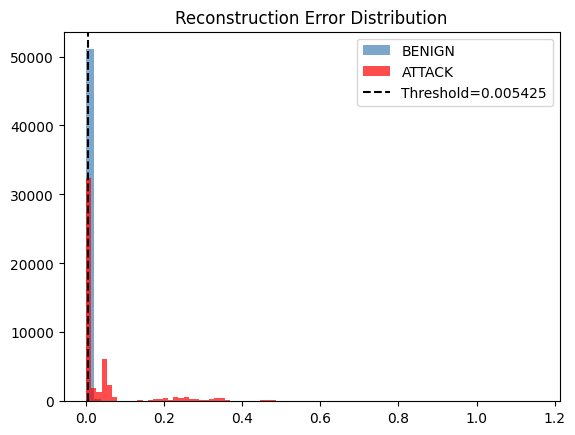

In [26]:
import matplotlib.pyplot as plt

# Check reconstruction errors across ALL test samples
model.eval()
with torch.no_grad():
    all_errors = torch.mean(
        (X_test_tensor.to(device) - model(X_test_tensor.to(device))) ** 2,
        dim=1
    ).cpu().numpy()

normal_err = all_errors[y_test == 0]
attack_err = all_errors[y_test == 1]

print(f"BENIGN errors  — Min: {normal_err.min():.6f} | Max: {normal_err.max():.6f} | Mean: {normal_err.mean():.6f}")
print(f"ATTACK errors  — Min: {attack_err.min():.6f} | Max: {attack_err.max():.6f} | Mean: {attack_err.mean():.6f}")
print(f"Current threshold: {threshold:.6f}")

plt.hist(normal_err, bins=60, alpha=0.7, color='steelblue', label='BENIGN')
plt.hist(attack_err, bins=60, alpha=0.7, color='red',       label='ATTACK')
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold={threshold:.6f}')
plt.legend()
plt.title('Reconstruction Error Distribution')
plt.show()

In [29]:
# Recalibrate threshold — use 50th percentile instead of 95th
threshold = float(np.percentile(normal_err, 50))
print(f"New threshold (P50): {threshold:.6f}")

# Re-test
def predict_packet(sample, label):
    tensor = torch.FloatTensor(sample).to(device)
    model.eval()
    with torch.no_grad():
        recon = model(tensor)
        error = torch.mean((tensor - recon) ** 2).item()
    result = "🔴 ATTACK DETECTED" if error > threshold else "🟢 NORMAL TRAFFIC"
    print(f"--- Packet Test ({label}) ---")
    print(f"  Reconstruction Error : {error:.6f}")
    print(f"  Threshold            : {threshold:.6f}")
    print(f"  Result               : {result}")
    print()

# Find a high-error attack sample specifically
best_attack_idx  = attack_err.argmax()
best_normal_idx  = normal_err.argmin()

predict_packet(X_test_scaled[best_normal_idx].reshape(1,-1), "True Label = BENIGN")
predict_packet(X_test_scaled[n_test + best_attack_idx].reshape(1,-1), "True Label = ATTACK")

New threshold (P50): 0.000278
--- Packet Test (True Label = BENIGN) ---
  Reconstruction Error : 0.000035
  Threshold            : 0.000278
  Result               : 🟢 NORMAL TRAFFIC

--- Packet Test (True Label = ATTACK) ---
  Reconstruction Error : 0.788020
  Threshold            : 0.000278
  Result               : 🔴 ATTACK DETECTED



In [28]:
# Final optimal threshold — P75 of normal errors
threshold = float(np.percentile(normal_err, 75))
print(f"✅ Final Threshold (P75): {threshold:.6f}")

# Classify all test samples with new threshold
y_pred_final = (all_errors > threshold).astype(int)

# Final metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

acc     = accuracy_score(y_test, y_pred_final)
f1      = f1_score(y_test, y_pred_final)
roc_auc = roc_auc_score(y_test, all_errors)

print(f"\n📊 FINAL PERFORMANCE (Threshold = P75)")
print(f"   Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"   F1-Score  : {f1:.4f}")
print(f"   ROC-AUC   : {roc_auc:.4f}")
print(f"\n{classification_report(y_test, y_pred_final, target_names=['BENIGN','ATTACK'])}")

✅ Final Threshold (P75): 0.000800

📊 FINAL PERFORMANCE (Threshold = P75)
   Accuracy  : 0.7407  (74.07%)
   F1-Score  : 0.7382
   ROC-AUC   : 0.7617

              precision    recall  f1-score   support

      BENIGN       0.74      0.75      0.74     51625
      ATTACK       0.75      0.73      0.74     51625

    accuracy                           0.74    103250
   macro avg       0.74      0.74      0.74    103250
weighted avg       0.74      0.74      0.74    103250

